In [93]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import mysql.connector
import seaborn as sns

In [96]:
conn = mysql.connector.connect(# to connect to the MySQL database
    host="127.0.0.1",
    user="root",
    password="Catalyst@312",
    database="dagevolve"
)
cursor = conn.cursor()
df = pd.read_sql("SELECT * FROM gamesales", conn)

# Clean and convert
df["North America_Sales"] = (
    df["North America_Sales"]
    .replace(["", "N/A", "NA", None], 0)
    .astype(float)
    .astype(int)
)

C:\Users\Tonika Price\AppData\Local\Temp\ipykernel_6064\3262166239.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM gamesales", conn)


In [98]:
query = """
SELECT 
    CAST(
        NULLIF(REPLACE(North_America_Sales, ',', ''), '') 
        AS UNSIGNED
    ) AS North_America_Sales,
    *
FROM gamesales;
"""

In [99]:
cursor.execute("SELECT * FROM GameSales;")
df = pd.DataFrame(cursor.fetchall(), columns=[col[0] for col in cursor.description])
df.head()

,Name,Console,Year,Genre,Company,North America_Sales,Europe_Sales,Japan_Sales,Global_Sales
0,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,82.74
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,40.24
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,35.82
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,33.00
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,31.37


In [100]:
cursor.execute("DESCRIBE gamesales;")
cursor.fetchall()

[('Name', 'text', 'YES', '', None, ''),
 ('Console', 'varchar(50)', 'YES', '', None, ''),
 ('Year', 'int', 'YES', '', None, ''),
 ('Genre', 'text', 'YES', '', None, ''),
 ('Company', 'varchar(255)', 'YES', '', None, ''),
 ('North America_Sales', 'decimal(5,2)', 'YES', '', None, ''),
 ('Europe_Sales', 'decimal(5,2)', 'YES', '', None, ''),
 ('Japan_Sales', 'decimal(5,2)', 'YES', '', None, ''),
 ('Global_Sales', 'double', 'YES', '', None, '')]

In [101]:
import pandas as pd

cursor.execute("SELECT * FROM gamesales ORDER BY Genre DESC;")# to get all the data from the GameSales table ordered by Genre in descending order
df = pd.DataFrame(cursor.fetchall(), columns=[col[0] for col in cursor.description])
df.head()

,Name,Console,Year,Genre,Company,North America_Sales,Europe_Sales,Japan_Sales,Global_Sales
0,Worms 2,PC,1997,Strategy,Microprose,0.00,0.01,0.00,0.01
1,Total War Attila: Tyrants & Kings,PC,2016,Strategy,Koch Media,0.00,0.01,0.00,0.01
2,Ishin no Arashi: Shippuu Ryuumeden,DS,2010,Strategy,Tecmo Koei,0.00,0.00,0.01,0.01
3,Hospital Tycoon,PC,2007,Strategy,Codemasters,0.00,0.01,0.00,0.01
4,Shutsugeki! Otometachi no Senjou 2: Ikusabana ...,PSP,2011,Strategy,System Soft,0.00,0.00,0.01,0.01


In [102]:
query = """
    SELECT Genre, Global_Sales
    FROM gamesales
"""
cursor.execute(query)
rows = cursor.fetchall()
cols = [col[0] for col in cursor.description]


In [103]:
import pandas as pd

df_vgsales = pd.DataFrame(rows, columns=cols)
df_vgsales.head()


,Genre,Global_Sales
0,Sports,82.74
1,Platform,40.24
2,Racing,35.82
3,Sports,33.00
4,Role-Playing,31.37


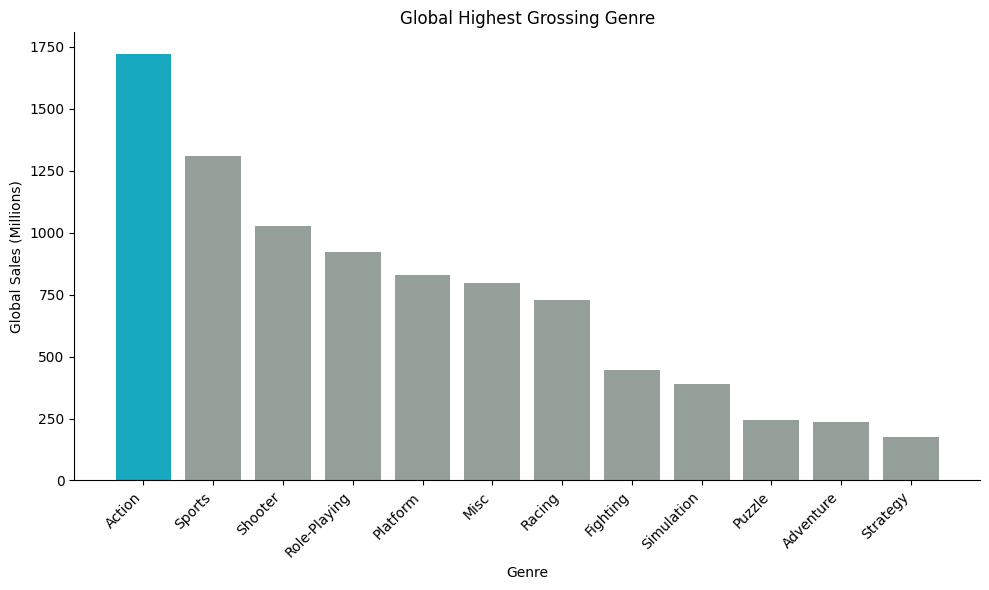

In [104]:
import matplotlib.pyplot as plt


Genre = df_vgsales.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#959f99'] * len(Genre)

max_index = Genre.idxmax()
highlight_position = Genre.index.get_loc(max_index)
colors[highlight_position] = '#17a9bf'

plt.bar(Genre.index, Genre.values, color=colors, width=0.8)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel("Genre")
plt.ylabel("Global Sales (Millions)")
plt.title("Global Highest Grossing Genre")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()




In [105]:
query = """
    SELECT Company, Global_Sales
    FROM gamesales
"""
cursor.execute(query)
rows = cursor.fetchall()
cols = [col[0] for col in cursor.description]

import pandas as pd
df_vgsales = pd.DataFrame(rows, columns=cols)

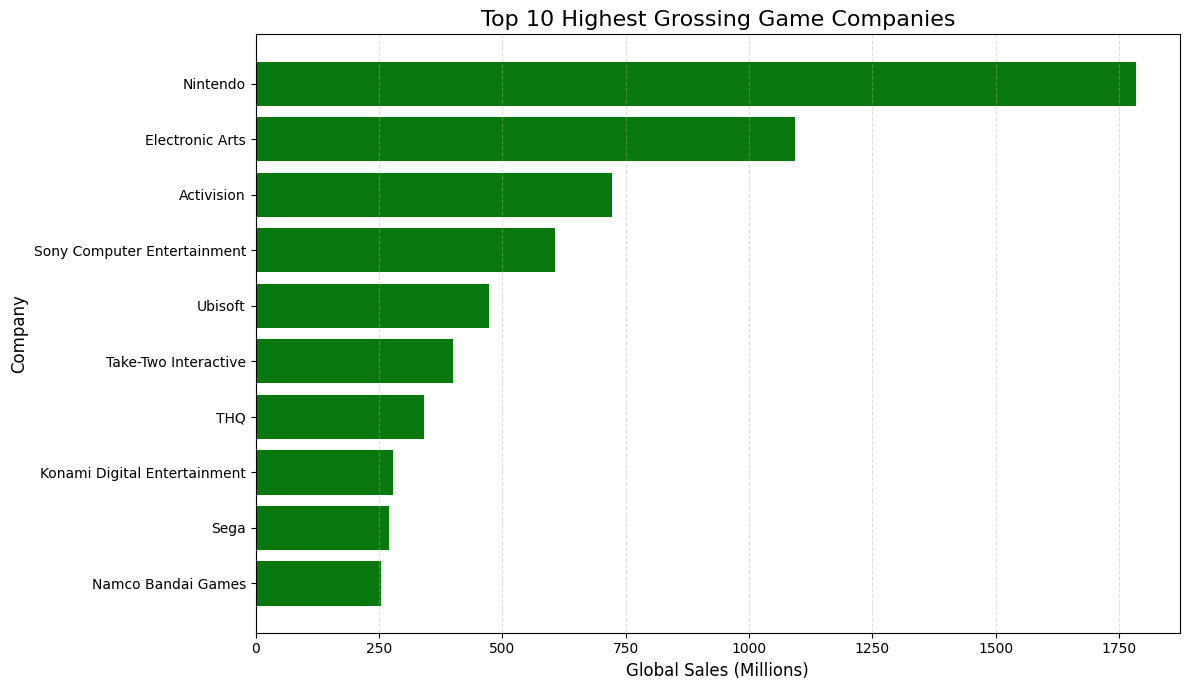

In [106]:
import matplotlib.pyplot as plt

Company_sales = (
    df_vgsales.groupby("Company")["Global_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12, 7))

plt.barh(
    Company_sales["Company"],
    Company_sales["Global_Sales"],
    color="#08770e"
)

plt.title("Top 10 Highest Grossing Game Companies", fontsize=16)
plt.xlabel("Global Sales (Millions)", fontsize=12)
plt.ylabel("Company", fontsize=12)

plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [115]:
query = """
    SELECT 
        Console,
        Global_Sales,
        
        Japan_Sales,
        Europe_Sales
    FROM gamesales
"""
cursor.execute(query)
rows = cursor.fetchall()
cols = [col[0] for col in cursor.description]

df_vgsales = pd.DataFrame(rows, columns=cols)


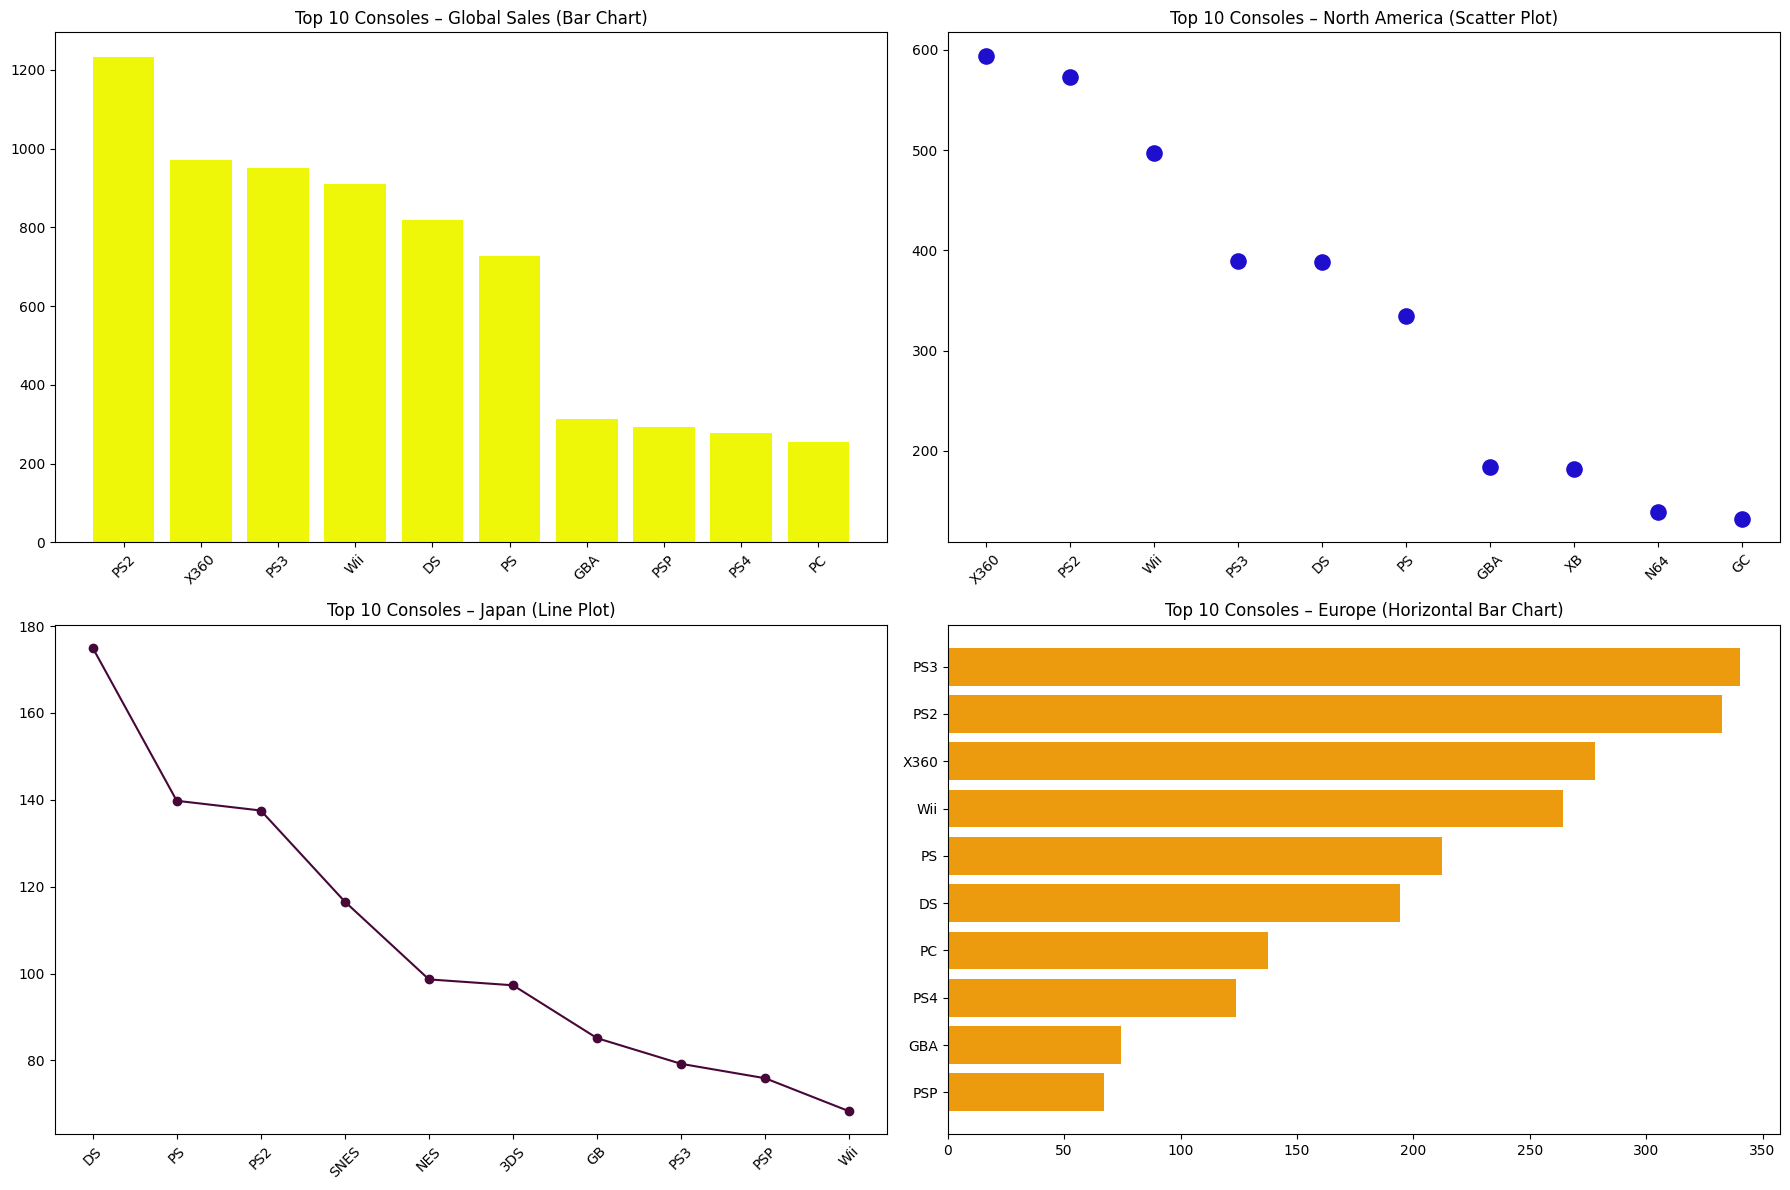

In [117]:
# Create top 10 for each region
global_sales = (
    df.groupby("Console")["Global_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

na_sales = (
    df.groupby("Console")["North America_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

jp_sales = (
    df.groupby("Console")["Japan_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

eu_sales = (
    df.groupby("Console")["Europe_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# --- 1. Global: Bar Chart ---
axes[0, 0].bar(global_sales["Console"], global_sales["Global_Sales"], color="#EFF708")
axes[0, 0].set_title("Top 10 Consoles – Global Sales (Bar Chart)")
axes[0, 0].tick_params(axis="x", rotation=45)

# --- 2. North America: Scatter Plot ---
axes[0, 1].scatter(na_sales["Console"], na_sales["North America_Sales"], color="#1E0ECD", s=120)
axes[0, 1].set_title("Top 10 Consoles – North America (Scatter Plot)")
axes[0, 1].tick_params(axis="x", rotation=45)

# --- 3. Japan: Line Plot ---
axes[1, 0].plot(jp_sales["Console"], jp_sales["Japan_Sales"], marker="o", color="#470738")
axes[1, 0].set_title("Top 10 Consoles – Japan (Line Plot)")
axes[1, 0].tick_params(axis="x", rotation=45)

# --- 4. Europe: Horizontal Bar Chart ---
axes[1, 1].barh(eu_sales["Console"], eu_sales["Europe_Sales"], color="#ED9B0E")
axes[1, 1].set_title("Top 10 Consoles – Europe (Horizontal Bar Chart)")
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()



In [118]:
query = """
SELECT *
FROM gamesales
ORDER BY Console DESC 
LIMIT 20;
"""

cursor.execute(query)# to get the top 20 consoles ordered by Console in descending order
rows = cursor.fetchall()
cols = [col[0] for col in cursor.description]

import pandas as pd
Console = pd.DataFrame(rows, columns=cols)
Console.head()

,Name,Console,Year,Genre,Company,North America_Sales,Europe_Sales,Japan_Sales,Global_Sales
0,Goat Simulator,XOne,2016,Simulation,Koch Media,0.00,0.01,0.00,0.01
1,Hitman (2016),XOne,2016,Action,Square Enix,0.00,0.01,0.00,0.01
2,Rabbids Invasion: The Interactive TV Show,XOne,2014,Misc,Ubisoft,0.00,0.01,0.00,0.01
3,Rugby League Live 3,XOne,2015,Action,Tru Blu Entertainment,0.00,0.01,0.00,0.01
4,Mighty No. 9,XOne,2016,Platform,Deep Silver,0.01,0.00,0.00,0.01


In [119]:
query = """
SELECT
    'Game',
    Global_Sales
FROM gamesales
ORDER BY Global_Sales DESC
LIMIT 10;
"""

cursor.execute(query)
rows = cursor.fetchall()
cols = [col[0] for col in cursor.description]

import pandas as pd
Global_Sales = pd.DataFrame(rows, columns=cols)
Global_Sales = Global_Sales.set_index("Game")#  to set the index of the DataFrame to the Game column

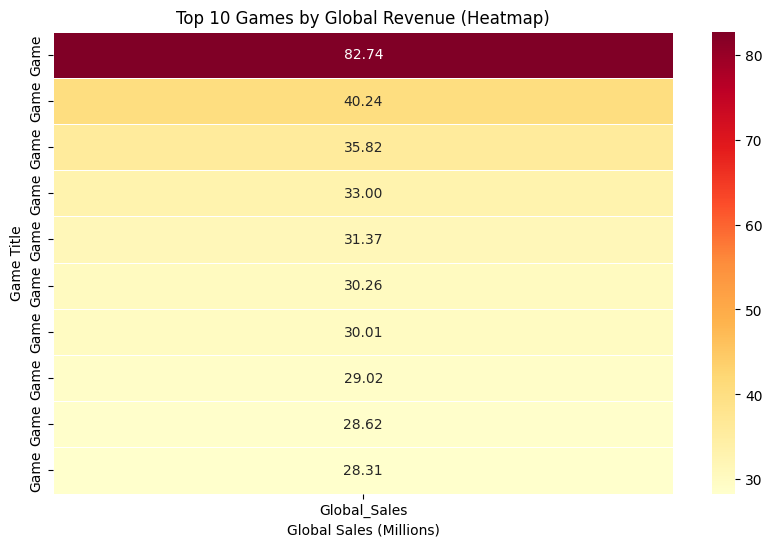

In [120]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(
    Global_Sales[['Global_Sales']],
    annot=True,
    cmap='YlOrRd',
    linewidths=.5,
    fmt=".2f"
)

plt.title("Top 10 Games by Global Revenue (Heatmap)")# to create a heatmap of the top 10 games by global revenue
plt.ylabel("Game Title")
plt.xlabel("Global Sales (Millions)")
plt.show()

In [121]:
query = """
SELECT 
    'North America' AS Region,
    SUM(North_America_Sales) AS Total_Sales
FROM gamesales

UNION ALL

SELECT 
    'Europe' AS Region,
    SUM(Europe_Sales) AS Total_Sales
FROM gamesales

UNION ALL

SELECT 
    'Japan' AS Region,
    SUM(Japan_Sales) AS Total_Sales
FROM gamesales;
"""

In [ ]:
cursor.execute(query)
rows = cursor.fetchall()
cols = [col[0] for col in cursor.description]

import pandas as pd
region_sales = pd.DataFrame(rows, columns=cols)# to create a DataFrame from the query results with columns 'Region' and 'Total_Sales'

In [124]:
region_sales = region_sales.sort_values(
    by="Total_Sales",
    ascending=False
)
print(region_sales)# to print the region_sales DataFrame sorted by Total_Sales in descending order

          Region  Total_Sales
0  North America          0.0
1         Europe          0.0
2          Japan          0.0


In [125]:
query = """
SELECT 
    'North America' AS Region,
    SUM(North_America_Sales) AS Total_Sales
FROM gamesales

UNION ALL

SELECT 
    'Europe' AS Region,
    SUM(Europe_Sales) AS Total_Sales
FROM gamesales

UNION ALL

SELECT 
    'Japan' AS Region,
    SUM(Japan_Sales) AS Total_Sales
FROM gamesales;
"""

In [ ]:
cursor.execute(query)
rows = cursor.fetchall()
cols = [col[0] for col in cursor.description]

import pandas as pd
region_sales = pd.DataFrame(rows, columns=cols)# to create a DataFrame from the query results with columns 'Region' and 'Total_Sales'

regions = region_sales["Region"].tolist()# to convert the 'Region' column of the region_sales DataFrame to a list
sales = region_sales["Total_Sales"].tolist()# to convert the 'Total_Sales' column of the region_sales DataFrame to a list

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.pie(
    sales,
    labels=regions,
    autopct="%1.1f%%",
    startangle=140,
    colors=["#0adb11", "#66b3ff", "#f0e84e"]
)# to create a pie chart of total video game revenue by region with specified colors and percentage labels

plt.title("Total Video Game Revenue by Region")
plt.show()